In [1]:
pip install matplotlib yfinance networkx scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# ensure we can import the local padic_portfolio package
sys.path.append(os.path.abspath('..'))
import padic_portfolio.topology.metric as topo
import padic_portfolio.allocation.hrp as alloc

import pandas as pd
import yfinance as yf

In [3]:
# ---------------------------------------------------------------
# Pull the current S&P 500 constituent list from a GitHub mirror
# of the Wikipedia table.  Dots in tickers (e.g. BRK.B) are
# replaced with hyphens to match Yahoo Finance conventions.
# ---------------------------------------------------------------
url = ("https://raw.githubusercontent.com/datasets/"
       "s-and-p-500-companies/main/data/constituents.csv")
sp500 = pd.read_csv(url)
tickers = sp500['Symbol'].str.replace('.', '-', regex=False).tolist()

# CRITICAL FIX: Drop duplicate share classes to prevent rho=1.0 and log(0) errors
# These are the standard S&P 500 secondary classes.
dual_classes_to_drop = {'GOOGL', 'FOXA', 'NWS', 'UHAL-B'}
tickers = [t for t in tickers if t not in dual_classes_to_drop]

ticker_sector = dict(zip(
    sp500['Symbol'].str.replace('.', '-', regex=False),
    sp500['GICS Sector']
))
print(f"S&P 500 constituent list (filtered): {len(tickers)} tickers")

# ---------------------------------------------------------------
# Download daily adjusted closing prices: Jan 2018 – Dec 2023.
# Drop tickers with >5% missing observations, then forward-fill
# and back-fill any remaining gaps.
# ---------------------------------------------------------------
# Note: auto_adjust=True is deprecated in newer yfinance versions, 
# but it still works. We use it to ensure dividends/splits are handled.
data = yf.download(tickers, start="2018-01-01", end="2024-01-01", auto_adjust=True)
close = data["Close"].dropna(axis=1, how="all")

# Keep only tickers that actually downloaded
valid_tickers = [t for t in tickers if t in close.columns]
close = close[valid_tickers]

# Drop tickers with >5% missing data
threshold = 0.05 * len(close)
missing = close.isnull().sum()
bad = missing[missing > threshold].index.tolist()
if bad:
    print(f"Dropping {len(bad)} tickers with >5% missing")
    close = close.drop(columns=bad)
    valid_tickers = [t for t in valid_tickers if t not in bad]

close = close.ffill().bfill()

# Update sector map to valid tickers only
ticker_sector = {t: ticker_sector.get(t, 'Unknown') for t in valid_tickers}
N = len(valid_tickers)
print(f"Final universe: N = {N}, T = {len(close)} trading days")
print(f"Date range: {close.index[0].date()} to {close.index[-1].date()}")

S&P 500 constituent list (filtered): 499 tickers


[*                      2%                       ]  9 of 499 completed$SNDK: possibly delisted; no price data found  (1d 2018-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1514782800, endDate = 1704085200")
[********************* 44%                       ]  222 of 499 completed$GEV: possibly delisted; no price data found  (1d 2018-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1514782800, endDate = 1704085200")
[**********************71%*********              ]  354 of 499 completed$SOLV: possibly delisted; no price data found  (1d 2018-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1514782800, endDate = 1704085200")
[**********************87%*****************      ]  436 of 499 completed$Q: possibly delisted; no price data found  (1d 2018-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1514782800, endDate = 1704085200")
[*********************100%***********************]  499 of 499 com

Dropping 21 tickers with >5% missing
Final universe: N = 474, T = 1509 trading days
Date range: 2018-01-02 to 2023-12-29


In [4]:
# calculate returns right here so memory cannot lose it
returns = close.pct_change().dropna()

# backtest setup
lookback = 252  
step = 21       

strat_rets = []
bench_rets = []
alphas = [] #store scaling exponents

print(f"Running rolling backtest over {len(returns)} days...")

Running rolling backtest over 1508 days...


In [5]:
# main loop 
for t in range(lookback, len(returns), step):
    
    # 1. In-sample window 
    window = returns.iloc[t - lookback : t]
    corr = window.corr()
    
    # 2. topology and scaling exponent
    dist = topo.correlation_to_distance(corr)
    
    #single linkage cluster
    linkage_mat = topo.execute_slc(dist)

    #extract ultrametric structure
    ultra = topo.extract_ultrametric(linkage_mat, corr.columns)
    
    #calculate alpha_t for window
    alpha_t, r2_t = topo.calculate_scaling_exponent(linkage_mat, p=2)
    alphas.append({'date': returns.index[t], 'alpha': alpha_t})

    #3. allocation
    w_series = alloc.allocate_hrp(ultra, window)
    w = w_series.reindex(corr.columns).fillna(0).values 
    
    #4. out-of-sample forward returns
    forward = returns.iloc[t : t + step]
    

    #5. strategy
    strat_wealth = (1 + forward).cumprod() * w
    strat_port_wealth = strat_wealth.sum(axis=1)
    strat_ret = strat_port_wealth.pct_change()
    strat_ret.iloc[0] = strat_port_wealth.iloc[0] - 1.0 # First day return
    strat_rets.extend(strat_ret)
    
    #benchmark (equal weight)
    w_eq = np.ones(forward.shape[1]) / forward.shape[1]
    bench_wealth = (1 + forward).cumprod() * w_eq
    bench_port_wealth = bench_wealth.sum(axis=1)
    bench_ret = bench_port_wealth.pct_change()
    bench_ret.iloc[0] = bench_port_wealth.iloc[0] - 1.0 # First day return
    bench_rets.extend(bench_ret)

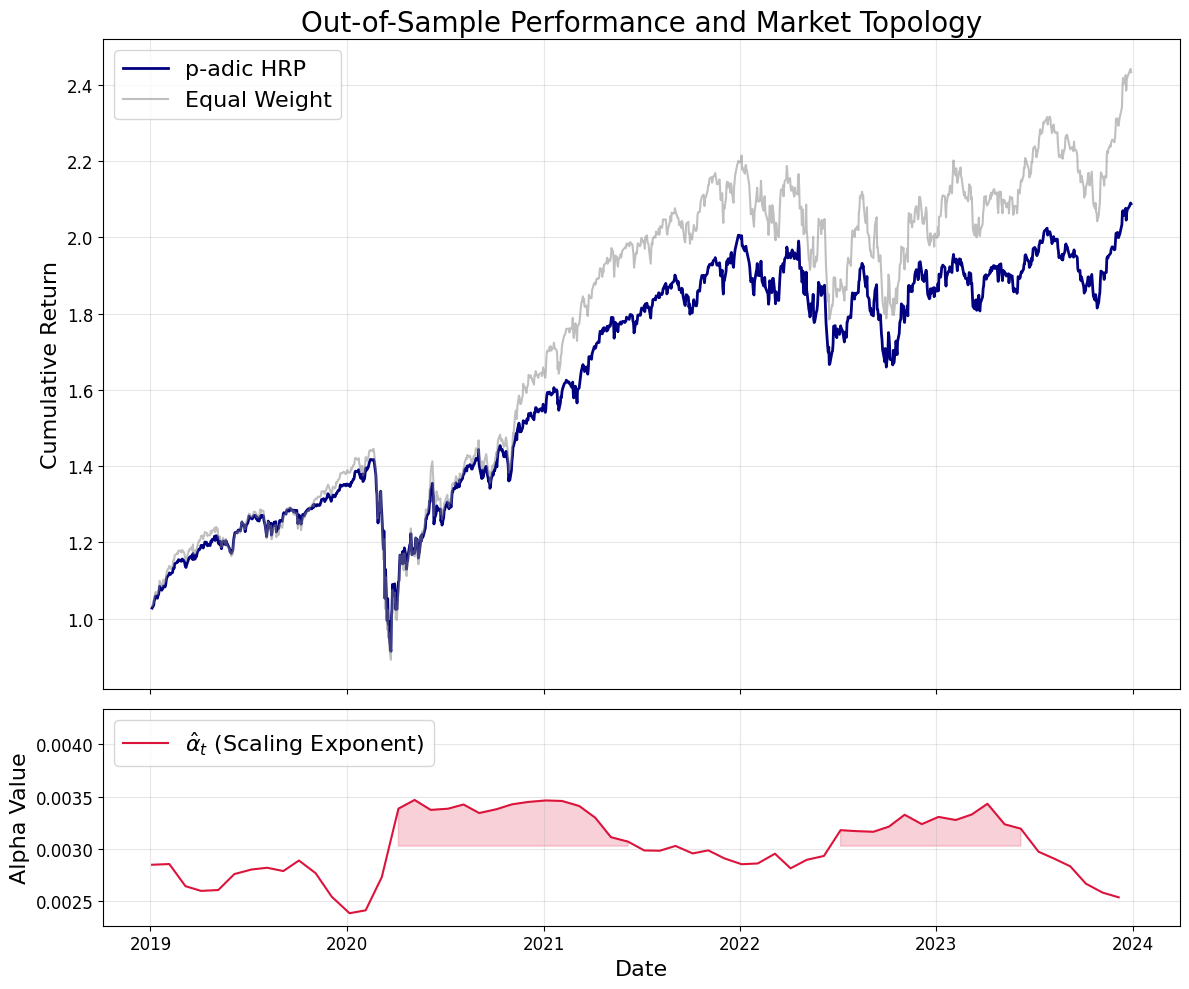

In [6]:
# plot
idx = returns.index[lookback : lookback + len(strat_rets)]
strat_cum = (1 + pd.Series(strat_rets, index=idx)).cumprod()
bench_cum = (1 + pd.Series(bench_rets, index=idx)).cumprod()

alpha_df = pd.DataFrame(alphas).set_index('date')

#dual panel plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,10), sharex=True, gridspec_kw={'height_ratios': [3,1]})

#plot 1: wealth curves
ax1.plot(strat_cum, label='p-adic HRP', color='navy', lw=2)
ax1.plot(bench_cum, label='Equal Weight', color='gray', alpha=0.5)
ax1.set_title('Out-of-Sample Performance and Market Topology', fontsize=20)
ax1.set_ylabel('Cumulative Return', fontsize=16)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=16)

#plot 2: scaling exponent
ax2.plot(alpha_df['alpha'], color='crimson', lw=1.5, label=r'$\hat{\alpha}_t$ (Scaling Exponent)')
ax2.set_ylabel('Alpha Value', fontsize=16)
ax2.set_xlabel('Date', fontsize=16)
ax2.legend(loc='upper left', fontsize=16)
ax2.grid(True, alpha=0.3)

# Highlight: If alpha is above its mean, shade the area (Market Stress Indicator)
mean_alpha = alpha_df['alpha'].mean()
ax2.fill_between(alpha_df.index, alpha_df['alpha'], mean_alpha, 
                 where=(alpha_df['alpha'] > mean_alpha), color='crimson', alpha=0.2)
max_alpha = alpha_df['alpha'].max()
ax2.set_ylim(bottom=alpha_df['alpha'].min() * 0.95, top=max_alpha * 1.25) # Adds 25% empty space at the top

ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

In [7]:
# 5. Risk-Adjusted Performance Metrics

def calculate_metrics(returns_series):
    # Annualized Return (assuming 252 trading days)
    ann_ret = returns_series.mean() * 252
    
    # Annualized Volatility
    ann_vol = returns_series.std() * np.sqrt(252)
    
    # Sharpe Ratio (assuming 0% risk-free rate for simplicity)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    
    # Maximum Drawdown
    cum_wealth = (1 + returns_series).cumprod()
    rolling_max = cum_wealth.cummax()
    drawdown = (cum_wealth - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    return ann_ret, ann_vol, sharpe, max_dd

# Convert the raw lists into Pandas Series using the 'idx' from the previous cell
strat_series_clean = pd.Series(strat_rets, index=idx)
bench_series_clean = pd.Series(bench_rets, index=idx)

# Calculate metrics for both strategies
strat_metrics = calculate_metrics(strat_series_clean)
bench_metrics = calculate_metrics(bench_series_clean)

# Format the output table
metrics_df = pd.DataFrame({
    'p-adic HRP': strat_metrics,
    'Equal Weight': bench_metrics
}, index=['Ann. Return', 'Ann. Volatility', 'Sharpe Ratio', 'Max Drawdown'])

print("\n--- Out-of-Sample Performance Metrics ---")
print(metrics_df.round(4))


--- Out-of-Sample Performance Metrics ---
                 p-adic HRP  Equal Weight
Ann. Return          0.1664        0.2033
Ann. Volatility      0.1925        0.2222
Sharpe Ratio         0.8645        0.9151
Max Drawdown        -0.3552       -0.3825
